In [10]:
# data sets
# from torch_geometric.datasets import QM9 # we will not be using QM9
from tdc.utils import get_reaction_type

# rdkit things
from rdkit import Chem
from rdkit.Chem import GetPeriodicTable
from rdkit.Chem import rdChemReactions
from rdkit.Chem import Draw
from rdkit.Chem.Draw import ReactionToImage
from rdkit.Chem.Draw import MolToImage

# standard libraries
import glob
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# machine learning libraries
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, global_mean_pool
from torch_geometric.data import Data
from sklearn.model_selection import train_test_split


### (1) Retrieve the cleaned data from data_exploration.ipynb to use in our model.

In [11]:
alchemy_elements = {'C', 'Cl', 'F', 'H', 'N', 'O', 'S'}
molecule_types_df = pd.read_csv("Collected Data/Alchemy-v20191129/final_version_with_smiles.csv")
reaction_types_df = pd.read_csv("Collected Data/uspto_50k_processed.csv")

display(molecule_types_df)
display(reaction_types_df)

,gdb_idx,atom number,"zpve\n(Ha, zero point vibrational energy)","Cv\n(cal/molK, heat capacity at 298.15 K)","gap\n(Ha, LUMO-HOMO)","G\n(Ha, Free energy at 298.15 K)","HOMO\n(Ha, energy of HOMO)","U\n(Ha, internal energy at 298.15 K)","alpha\n(a_0^3, Isotropic polarizability)","U0\n(Ha, internal energy at 0 K)","H\n(Ha, enthalpy at 298.15 K)","LUMO\n(Ha, energy of LUMO)","mu\n(D, dipole moment)","R2\n(a_0^2, electronic spatial extent)",smiles
0,2859833,9,0.226164,0.000067,0.300531,-352.128828,-0.236722,-352.076085,99.201621,-352.088194,-352.075141,0.063809,0.180558,1919.249225,CC#CC[C@H](C)CCC
1,3148292,9,0.180782,0.000058,0.293098,-386.820766,-0.241536,-386.774917,84.670738,-386.784878,-386.773973,0.051562,1.302656,1420.242859,C#CC[C@@H]1CO[C@@H]1CC
2,3607838,9,0.205922,0.000057,0.307544,-388.062328,-0.224965,-388.018758,86.198178,-388.028208,-388.017814,0.082579,1.284923,1257.238492,CC[C@H]1[C@H]2CCO[C@]21C
3,9540153,11,0.160845,0.000056,0.195923,-515.046508,-0.203538,-515.001198,95.801267,-515.010568,-515.000254,-0.007615,4.074910,1600.220066,COc1nccc2c1OCC2
4,340363,10,0.177712,0.000057,0.254495,-403.843164,-0.248943,-403.800346,95.147725,-403.809426,-403.799402,0.005552,4.111533,1442.171110,CC1=CC[C@H]2C[C@@H]2[C@H]1C#N
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
202574,9581016,10,0.120222,0.000051,0.179768,-450.915828,-0.244325,-450.872449,88.581216,-450.881390,-450.871505,-0.064557,6.434535,1541.115465,CNc1cc(C#N)ncn1
202575,9706527,10,0.130179,0.000053,0.189401,-438.632624,-0.231340,-438.589755,96.102362,-438.598674,-438.588811,-0.041938,0.338522,1628.839361,C#Cc1ccnc(OC)c1
202576,9760179,10,0.119919,0.000051,0.163827,-450.920199,-0.232783,-450.875248,89.074794,-450.884399,-450.874304,-0.068956,4.337358,1497.024559,CNc1nccc(C#N)n1
202577,9845175,10,0.119740,0.000050,0.191354,-454.722866,-0.251374,-454.680504,89.026059,-454.689065,-454.679560,-0.060020,5.263580,1611.219983,COc1cncc(C#N)c1


,reactant,product,category
0,C1=COCCC1.COC(=O)CCC(=O)c1ccc(O)cc1O,COC(=O)CCC(=O)c1ccc(OC2CCCCO2)cc1O,1
1,COC(=O)c1cccc(C(=O)O)c1.Nc1cccnc1N,COC(=O)c1cccc(-c2nc3cccnc3[nH]2)c1,4
2,CC(C)(C)OC(=O)NC1CCC(C(=O)O)CC1.CNOC,CON(C)C(=O)C1CCC(NC(=O)OC(C)(C)C)CC1,2
3,Nc1ccc(O)cc1.O=[N+]([O-])c1ccc(Cl)nc1Cl,O=[N+]([O-])c1ccc(Cl)nc1Nc1ccc(O)cc1,1
4,[N-]=[N+]=NCC1=CC[C@@H](c2ccc(Cl)cc2Cl)[C@H]([...,NCC1=CC[C@@H](c2ccc(Cl)cc2Cl)[C@H]([N+](=O)[O-...,9
...,...,...,...
35111,COC(=O)c1ccc(C(=O)OCc2ccccc2)cc1F,COC(=O)c1ccc(C(=O)O)cc1F,6
35112,C=CCOC(=O)N1CCc2nnc(NN)cc2C1.CC(C)=O,C=CCOC(=O)N1CCc2nnc(NN=C(C)C)cc2C1,1
35113,FC1(F)CCNC1.O=C(O)c1ccncc1NC(=O)c1nc(C2CC2)ccc...,O=C(Nc1cnccc1C(=O)N1CCC(F)(F)C1)c1nc(C2CC2)ccc...,2
35114,CC(=O)Cl.CC(C)(C)OC(=O)NCCO,CC(=O)OCCNC(=O)OC(C)(C)C,2


The GNN will take each molecule as a pooling of the atoms as nodes and the bonds as edges and lets each atom update its features by aggreating from its neighbors. After this messaging, pool atoms to molecule to predict the 13 features that will be used in the decsion tree for the reaction type. Now, though for the decision tree that takes in these 12 output features, I don't want redundancy. But, I will leave it temporarily for the GNN. 

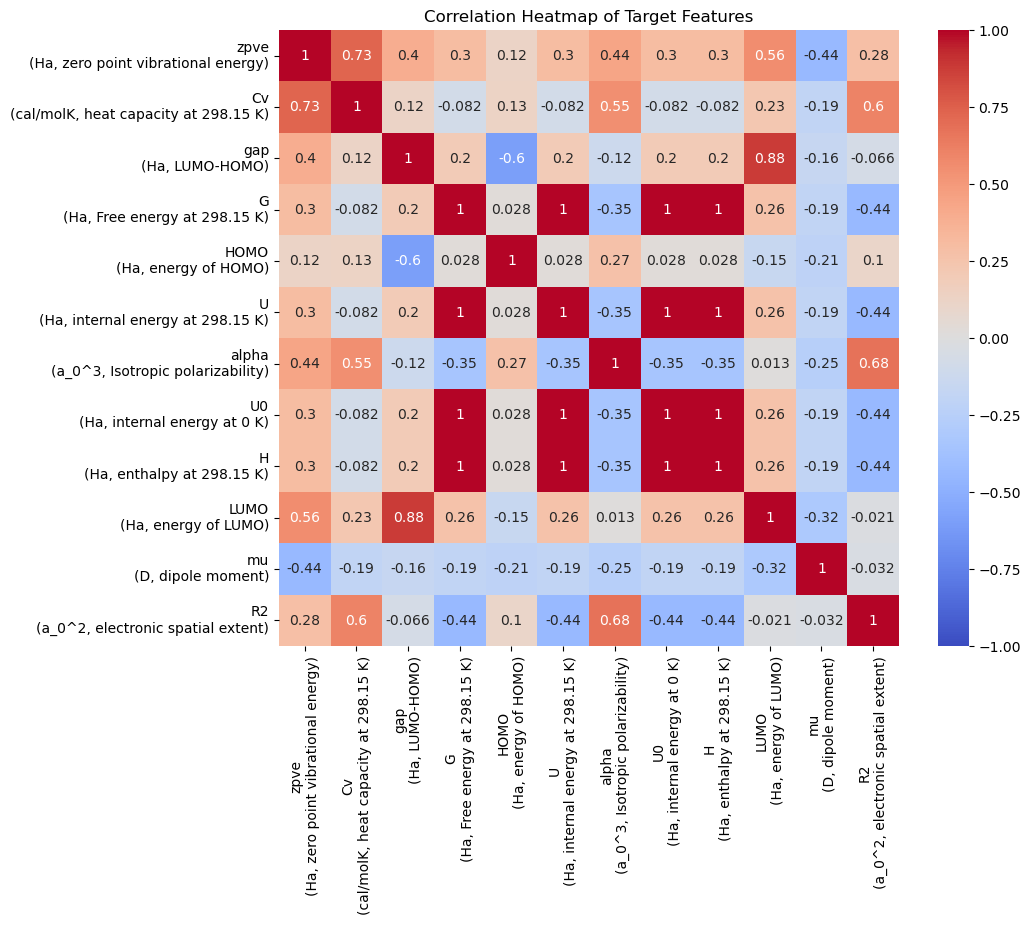

In [12]:
# just the target features for the molecules, which we will be trying to predict with our GNN and use as input into decision tree
# 12/15 are valid physics values for this model (smiles is already the graph, gdb_idx was just to help find smiles, atom number has no physics)
molecule_targets_df = molecule_types_df.drop(columns=['smiles', 'gdb_idx', 'atom number'])

# correlation heatmap of the target features
plt.figure(figsize=(10, 8))
sns.heatmap(molecule_targets_df.corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Correlation Heatmap of Target Features")
plt.show()

### (2) Focus on making the GNN with the alchemy DFT data. Use only a fraction of the data so I can practically run this.

In [13]:
# Create a smaller dataframe with a random sample of molecules from the alchemy dataset to work with locally. 

n_examples = 1000
small_molecule_types_df = molecule_types_df.sample(n=n_examples, random_state=67).reset_index(drop=True)
display(small_molecule_types_df)

,gdb_idx,atom number,"zpve\n(Ha, zero point vibrational energy)","Cv\n(cal/molK, heat capacity at 298.15 K)","gap\n(Ha, LUMO-HOMO)","G\n(Ha, Free energy at 298.15 K)","HOMO\n(Ha, energy of HOMO)","U\n(Ha, internal energy at 298.15 K)","alpha\n(a_0^3, Isotropic polarizability)","U0\n(Ha, internal energy at 0 K)","H\n(Ha, enthalpy at 298.15 K)","LUMO\n(Ha, energy of LUMO)","mu\n(D, dipole moment)","R2\n(a_0^2, electronic spatial extent)",smiles
0,82642,11,0.239593,0.000072,0.250232,-502.508749,-0.229935,-502.459791,102.959327,-502.471522,-502.458847,0.020297,1.512989,1967.048763,C[C@H]1CC=C([C@@H](C)O)COC1
1,6264428,10,0.211166,0.000063,0.253778,-463.251265,-0.233838,-463.205069,91.842329,-463.215543,-463.204124,0.019940,1.596246,1668.965710,C[C@@H]1CCC=C[C@H](CO)O1
2,8761235,10,0.188067,0.000058,0.210123,-462.067952,-0.224407,-462.022419,87.223858,-462.032162,-462.021475,-0.014284,3.297574,1615.944140,CCO[C@H]1C[C@@H]2C[C@@H]2C1=O
3,6640342,10,0.181395,0.000065,0.305293,-859.209539,-0.249505,-859.160915,88.868316,-859.172083,-859.159971,0.055788,3.884206,1885.743617,C[C@H]1OC[C@H]1CS(C)(=O)=O
4,153469,11,0.183893,0.000060,0.183995,-479.110377,-0.202056,-479.065248,101.050507,-479.075051,-479.064304,-0.018062,5.452225,1645.648609,CC1=CC(=O)[C@H]2CC=C[C@H]2N1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,2600595,10,0.214332,0.000058,0.250274,-388.967224,-0.218349,-388.925446,102.365968,-388.934063,-388.924502,0.031925,0.264720,1472.165960,C1=CC2(CC2)C[C@@H]2C[C@H]2C1
996,501308,11,0.180144,0.000062,0.211143,-839.173375,-0.227667,-839.124353,108.105143,-839.134962,-839.123409,-0.016524,2.589120,2091.790187,Cc1ncsc1[C@H]1CCCO1
997,4308539,10,0.234301,0.000067,0.264050,-427.330647,-0.228948,-427.283109,97.514632,-427.294048,-427.282165,0.035102,1.362797,1690.319539,CC(C)[C@@H](O)C1CC=CC1
998,694705,10,0.189837,0.000055,0.254181,-462.060417,-0.236941,-462.017726,89.057929,-462.026679,-462.016782,0.017240,2.423733,1533.890375,CC1=C[C@H]2COC[C@@H]2OC1


In [14]:
def smiles_to_graph(smi, y): 
    """
    Convert a SMILES string to a PyTorch Geometric Data object representing the molecular graph.
    Nodes represent atoms, and edges represent bonds. 
    """
    mol = Chem.MolFromSmiles(smi)
    if mol is None: return None
    
    # atom features
    atom_features = [atom.GetAtomicNum() for atom in mol.GetAtoms()]
    x = torch.tensor(atom_features, dtype=torch.float).unsqueeze(1)
    
    # edges
    edge_index = []
    for bond in mol.GetBonds():
        i = bond.GetBeginAtomIdx()
        j = bond.GetEndAtomIdx()
        edge_index.append((i, j))
        edge_index.append((j, i))
        # undirected graph, both directions
    
    # convert to tensor
    if len(edge_index) == 0:
        edge_index = torch.empty((2, 0), dtype=torch.long)
    else:
        edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()
    
    # targets
    y = torch.tensor(y, dtype=torch.float)

    return Data(x=x, edge_index=edge_index, y=y) # already is a class that can be used with DataLoader

In [15]:
# turn all the data into a graph for use in the GNN
# molecule_targets_df is the target columns

graph_dataset = []
for idx, row in small_molecule_types_df.iterrows():
    graph = smiles_to_graph(
        row['smiles'], 
        row[molecule_targets_df.columns].astype(float).values
    )
    if graph is not None:
        graph_dataset.append(graph)

g = graph_dataset[0]
print(g.x.shape)            # [num_atoms, 1]
print(g.edge_index.shape)   # [2, num_edges]
print(g.y.shape)            # should be 12
# okay great nothing exploded

torch.Size([11, 1])
torch.Size([2, 22])
torch.Size([12])


In [16]:
# normalize the targets

all_y = torch.stack([g.y for g in graph_dataset])
y_mean = all_y.mean(dim = 0)
y_std = all_y.std(dim = 0).clamp_min(1e-8) # avoid div by 0 error

for g in graph_dataset: 
    g.y = (g.y - y_mean) / y_std

In [17]:
class GNN(torch.nn.Module): 
    def __init__(self): 
        super().__init__()

        self.conv1 = GCNConv(1,64)
        self.conv2 = GCNConv(64,64)

        self.lin1 = nn.Linear(64,64)
        self.lin2 = nn.Linear(64,13) 
        # number of y predictions is here in case of future change

    def forward(self, x, edge_index, batch): 
        
        # message passing
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.conv2(x, edge_index)
        x = F.relu(x)
        # from graph to molecule
        # here batch is the molecule
        x = global_mean_pool(x, batch)
        # finally the prediction
        x = self.lin1(x)
        x = F.relu(x)
        x = self.lin2(x)
        return x
        
class Trainer: 
    def __init__(self, model, lr = 1e-3, device = "cpu"): 
        self.model = model.to(device)
        self.device = device 
        self.optimizer = torch.optim.Adam(self.model.parameters(), lr = lr)
        self.loss_function = torch.nn.MSELoss()

    def train_one_epoch(self, loader): 
        self.model.train() # training 'mode' as per tutorial 
        total_loss = 0.0

        for batch in loader: 
            batch = batch.to(self.device)

            self.optimizer.zero_grad() # grad not needed as we evaluate
            pred = self.model(batch.x, batch.edge_index, batch.batch)
            loss = self.loss_function(pred, batch.y)
            loss.backward() # find the gradients
            self.optimizer.step() # update the weights

            total_loss += loss.item()
        
        return total_loss / len(loader) # average loss per batch 
    
    # used for testing phase an
    @torch.no_grad()
    def evaluate(self, loader): 
        self.model.eval() # no londer training
        total_loss = 0.0

        for batch in loader: 
            batch = batch.to(self.device) 
            pred = self.model(batch.x, batch.edge_index, batch.batch) 
            loss = self.loss_function(pred, batch.y)
            total_loss += loss.item()
        
        return total_loss / len(loader) # average loss per batch
    
    def fit(self, train_loader, val_loader, epochs = 20, show_progress = True): 
        train_losses = []
        val_losses = []

        best_val = float("inf")
        best_train = None

        for epoch in range(1, epochs +1): 
            train_loss = self.train_one_epoch(train_loader)
            val_loss = self.evaluate(val_loader)

            train_losses.append(train_loss)
            val_losses.append(val_loss)

            if val_loss < best_val: 
                best_val = val_loss
                best_train = train_loss

            if show_progress: 
                print(f"Epoch {epoch}: train={train_loss:.4f}, val={val_loss:.4f}")

        return {
            "train_losses": train_losses,
            "val_losses": val_losses,
            "best_train_loss": best_train,
            "best_val_loss": best_val
        }


In [18]:
# this is the stucture from homework 7, I am going to appropriate for my needs

# def KFoldCrossValidation(
#     model_class, k, 
#     X_train, y_train, X_test, y_test, 
#     opt_method='adam', learning_rate=2e-3, batch_size=128, epoch=50, l2=0.0,
#     early_break=False,
#     **model_args
# ):
#     test_data = MnistDataset(X_test, y_test)
#     kf = KFold(n_splits=k, shuffle=True)
#     train_acc_list, test_acc_list = [], []
#     for i, (train_index, val_index) in enumerate(kf.split(X_train)):
#         print(f"Fold {i}:")
#         
#         train_data = MnistDataset(X_train[train_index], y_train[train_index])
#         val_data = MnistDataset(X_train[val_index], y_train[val_index])
#         
#         model = model_class(**model_args)
#         
#         trainer = Trainer(model, opt_method, learning_rate, batch_size, epoch, l2)
#         res = trainer.train(train_data, val_data)
#         train_acc_best = res['train_acc_list'][np.argmin(res['val_loss_list'])]
#         test_loss, test_acc = trainer.evaluate(test_data)
#         
#         train_acc_list.append(train_acc_best)
#         test_acc_list.append(test_acc)
#         
#         print(f"Training accuracy: {train_acc_best}")
#         print(f"Test accuracy: {test_acc}")
#         
#         if early_break:
#             break
#     
#     if not early_break:
#         print("Final results:")
#         print(f"Training accuracy: {np.mean(train_acc_list)}+/-{np.std(train_acc_list)}")
#         print(f"Test accuracy: {np.mean(test_acc_list)}+/-{np.std(test_acc_list)}")